# Superstore Sales Analysis - Python

## Project Overview
This project analyzes the Superstore sales dataset using Python 
The goal is to extract meaningful business insights across region, categories,customer segments and sales trends to support data-driven decision making.

**Dataset**: Superstore, 9994 rows , 22 columns  
**Tools**  : Python, Pandas, Seaborn, Matplotlib, Numpy  
**By**     : Bhomik Arora

In [1]:
#Importing Libraries and Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_excel(r"https://raw.githubusercontent.com/BhomikArora/superstore-python-analysis/refs/heads/main/Sample%20-%20Superstore.xlsx")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Discount Value,Profit
0,1,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,0.000000,41.91
1,2,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,0.000000,219.58
2,3,CA-2016-138688,2016-12-06 00:00:00,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,0.000000,6.87
3,4,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,783.474545,-383.03
4,5,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,5.592500,2.52


## Section 1: Exploring Data
Exploring and understanding data's shape, data type, missing values and basic statistics.

In [2]:
df[['Sales','Quantity','Discount','Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858022,3.789574,0.156203,28.656973
std,623.245131,2.225110,0.206452,234.260203
min,0.440000,1.000000,0.000000,-6599.980000
25%,17.280000,2.000000,0.000000,1.730000
50%,54.490000,3.000000,0.200000,8.665000
75%,209.940000,5.000000,0.200000,29.360000
max,22638.480000,14.000000,0.800000,8399.980000


In [3]:
# Understanding Data
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          9994 non-null   int64  
 1   Order ID        9994 non-null   object 
 2   Order Date      9994 non-null   object 
 3   Ship Date       9994 non-null   object 
 4   Ship Mode       9994 non-null   object 
 5   Customer ID     9994 non-null   object 
 6   Customer Name   9994 non-null   object 
 7   Segment         9994 non-null   object 
 8   Country         9994 non-null   object 
 9   City            9994 non-null   object 
 10  State           9994 non-null   object 
 11  Postal Code     9994 non-null   int64  
 12  Region          9994 non-null   object 
 13  Product ID      9994 non-null   object 
 14  Category        9994 non-null   object 
 15  Sub-Category    9994 non-null   object 
 16  Product Name    9994 non-null   object 
 17  Sales           9994 non-null   f

(9994, 22)

In [4]:
np.unique(df.Category)

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [5]:
np.unique(df.Region)

array(['Central', 'East', 'South', 'West'], dtype=object)

In [6]:
df['Order Date']= pd.to_datetime(df['Order Date'])
date1=df['Order Date'].min()
date2=df['Order Date'].max()
print(f"First Date is:{date1.strftime('%Y-%m-%d')}")
print(f"Last Date is:{date2.strftime('%Y-%m-%d')}")

First Date is:2014-01-02
Last Date is:2017-12-30


### Key Insights
* Dataset contains 9,994 orders across 4 regions and 3 product categories spanning 4 years (2014-2017).
* No critical missing values found.
* Data is clean and ready for analysis.

## Section 2: Regional Sales Performance
Analysis which region generates the highest revenue.  
This helps identify top performing markets and underperforming areas.

In [7]:
region=df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(f'Highest sales is by {region.index[0]} with total of {region.iloc[0]:,.2f} and lowest by {region.index[-1]} with total of {region.iloc[-1]:,.2f}')

Highest sales is by West with total of 725,457.93 and lowest by South with total of 391,721.90


In [8]:
category=df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(f'The most profitable is {category.index[0]} having a total profit of ${category.iloc[0]:,.2f} and the least is {category.index[-1]} having a total profit of ${category.iloc[-1]:,.2f}')

The most profitable is Technology having a total profit of $145,455.66 and the least is Furniture having a total profit of $18,451.25


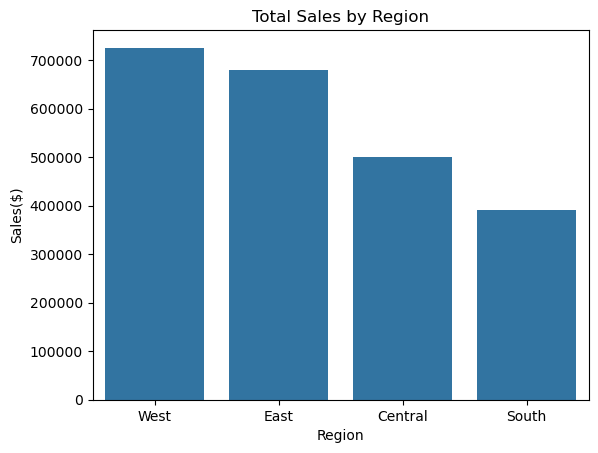

In [9]:
sns.barplot(x=region.index, y=region.values)
plt.title('Total Sales by Region')
plt.ylabel('Sales($)')
plt.show()

### Section 2.1: Why South is Underperforming?
South region has the lowest sales at $391K and 85% below West.  
We'll perform some tests to find the root cause.

#### Test 1: Is South receiving lower discounts?  
If South gets fewer discounts, customers may prefer competitors.

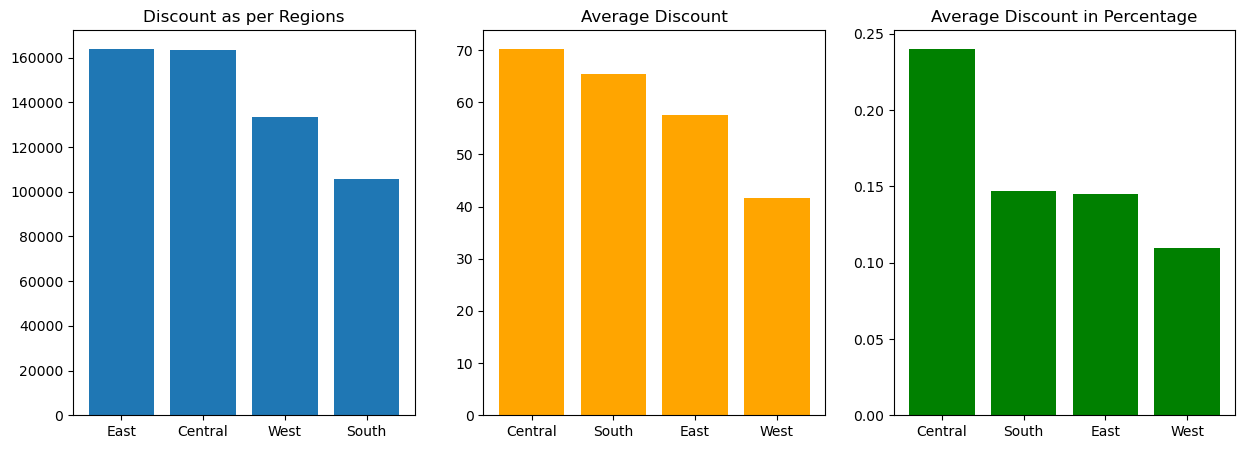

In [10]:
fig , axes = plt.subplots(1,3,figsize=(15,5))
# Total discount by regions
cat_discount=df.groupby('Region')['Discount Value'].sum().sort_values(ascending=False)
axes[0].bar(cat_discount.index,cat_discount.values)
axes[0].set_title('Discount as per Regions')

# Average disount by regions
cat_avg_dis=df.groupby('Region')['Discount Value'].mean().sort_values(ascending=False)
axes[1].bar(cat_avg_dis.index,cat_avg_dis.values,color='orange')
axes[1].set_title('Average Discount')

# Average disount by regions in percentage
cat_avg_is=df.groupby('Region')['Discount'].mean().sort_values(ascending=False)
axes[2].bar(cat_avg_is.index,cat_avg_is.values, color='green')
axes[2].set_title('Average Discount in Percentage')
plt.show()

**Result: REJECTED** South actually has the second highest average discount which means discounts are NOT the issue.

#### Test 2: Does South have fewer customers?
Lower footfall would directly explain lower revenue.

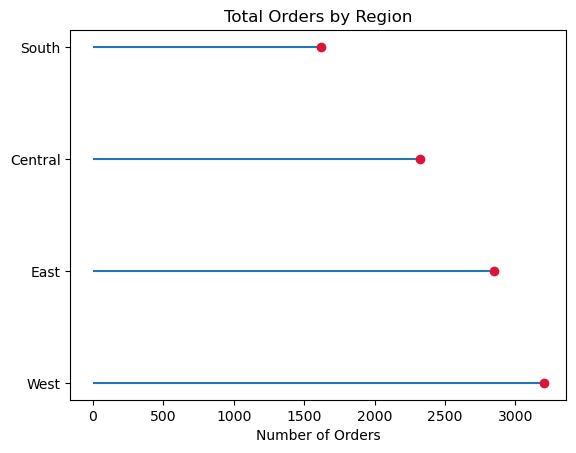

In [11]:
footfall=df.groupby('Region')['Order ID'].count().sort_values(ascending=False)
plt.hlines(y=footfall.index, xmin=0, xmax=footfall.values) 
plt.plot(footfall.values, footfall.index,'o', color='crimson')
plt.title('Total Orders by Region')
plt.xlabel('Number of Orders')
plt.show()

**Result: CONFIRMED** South has significantly fewer orders 
compared to West and East, suggesting lower market penetration.

#### Test 3: Are South customers not returning?  
Low repeat rate would indicate customer dissatisfaction.

In [12]:
customers = df.groupby(['Region', 'Customer ID']).size().reset_index(name='Orders_Per_Customer')
avg_repeat = customers.groupby('Region')['Orders_Per_Customer'].mean().round(2)
print("Average orders per customer by region:")
print(avg_repeat)
print()
one_time = customers[customers['Orders_Per_Customer'] == 1].groupby('Region').size()
total_customers = customers.groupby('Region').size()
one_per = (one_time / total_customers * 100).round(1)
print("One time only customers (%):")
print(one_per)

Average orders per customer by region:
Region
Central    3.69
East       4.23
South      3.16
West       4.67
Name: Orders_Per_Customer, dtype: float64

One time only customers (%):
Region
Central    23.7
East       18.5
South      27.5
West       16.0
dtype: float64


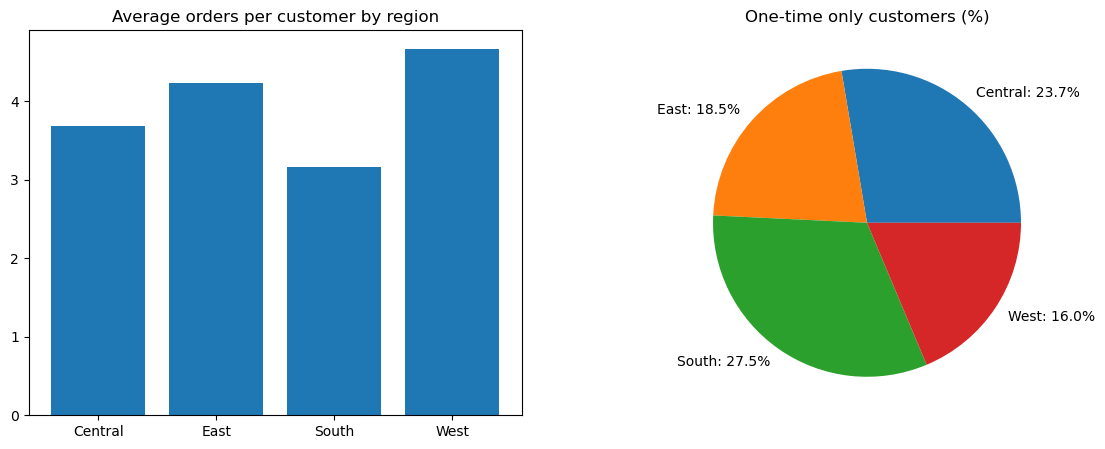

In [13]:
fig , axes= plt.subplots(1,2,figsize=(14,5))
#Repeat rate
axes[0].bar(avg_repeat.index,avg_repeat.values)
axes[0].set_title('Average orders per customer by region')

# Create custom labels that combine region names with percentage values
custom_labels = [f'{region}: {value:.1f}%' for region, value in zip(one_per.index, one_per.values)]
axes[1].pie(one_per.values, labels=custom_labels)
axes[1].set_title("One-time only customers (%)")
plt.show()

**Result: CONFIRMED** South has the lowest repeat rate 3.16 avg orders and the highest one-time customer rate at 27.5%  meaning more than 1 in 4 South customers never returns after their first purchase.

### Key Insights

* West region leads with **725K USD** in total sales, followed by East 678K USD, Central 501K USD and South 391 USD.
* West region generated **85.2%** more sales than South a difference of **333,735 USD**.
* Root cause of South underperformance identified through 3 factor analysis:
  *  Discounts :- NOT the issue (South has second highest avg discount)
  *  Low footfall :- South has only 1,620 orders vs West's 3,203.
  *  Poor retention :- 27.5% of South customers never return highest one time buyer rate across all regions
* South needs targeted customer acquisition and retention strategy, not pricing changes.

## Section 3: Analyzing Value & Margin Leaks
Analyzing which product category generates the most profit.


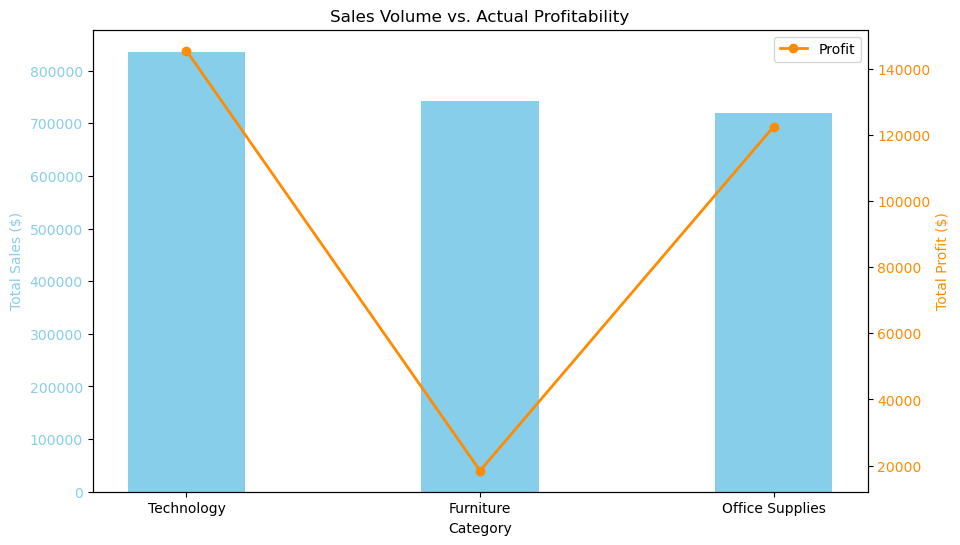

In [14]:
comparison= df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)
fig, sales= plt.subplots(figsize=(10, 6))
color = 'skyblue'
sales.set_xlabel('Category')
sales.set_ylabel('Total Sales ($)', color=color)
sales.bar(comparison.index, comparison['Sales'], color=color, width=0.4, label='Sales', align='center')
sales.tick_params(axis='y', labelcolor=color)
profit = sales.twinx()  
color = 'darkorange'
profit.set_ylabel('Total Profit ($)', color=color)
profit.plot(comparison.index, comparison['Profit'], color=color, marker='o', linewidth=2, label='Profit')
profit.tick_params(axis='y', labelcolor=color)
plt.title('Sales Volume vs. Actual Profitability')
plt.legend()
plt.show()

### Section 3.1: Why Does Furniture Have High Sales But Low Profit?
High sales with low profit usually means one thing the business is selling a lot but keeping very little.  
We dig into Furniture sub-categories to find exactly where the money is being lost.

In [15]:
discount=df.groupby('Category')['Discount Value'].sum().sort_values(ascending=False)
discount

Category
Technology         202258.185754
Furniture          185239.676691
Office Supplies    179236.429444
Name: Discount Value, dtype: float64

In [16]:
furniture = df[df['Category'] == 'Furniture']
sub_dis= furniture.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=False).round(2)
sub_dis

Sub-Category
Tables         0.26
Bookcases      0.21
Chairs         0.17
Furnishings    0.14
Name: Discount, dtype: float64

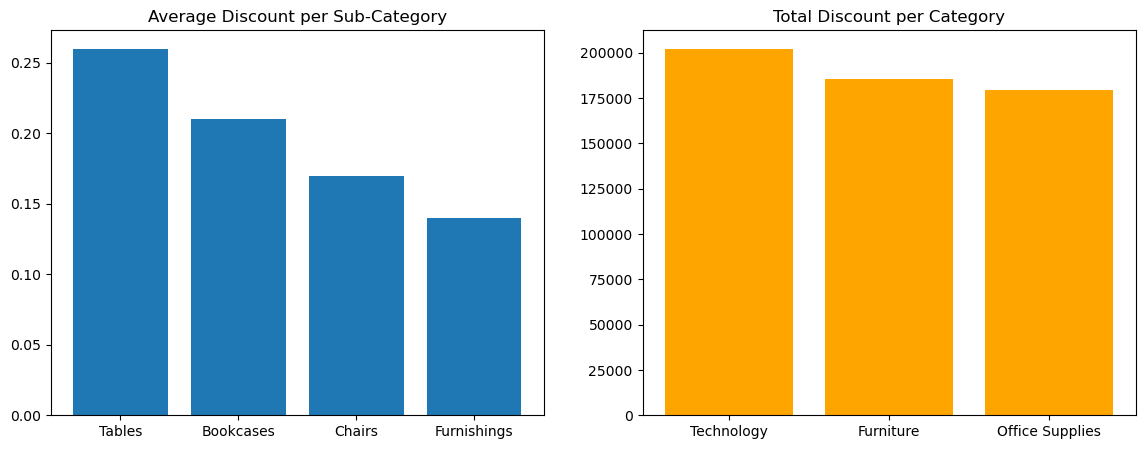

In [17]:
fig , axes = plt.subplots(1,2, figsize=(14,5))
# Average discount in sub category
axes[0].bar(sub_dis.index,sub_dis.values)
axes[0].set_title('Average Discount per Sub-Category')

# Sales and Profit as per Sub-Category
axes[1].bar(discount.index,discount.values,color='orange')
axes[1].set_title('Total Discount per Category')
plt.show()

In [18]:
sub_profit = furniture.groupby('Sub-Category')[['Sales','Profit']].sum().sort_values(by='Profit', ascending=False)
sub_profit

,Sales,Profit
Sub-Category,,
Chairs,328449.13,26590.15
Furnishings,91705.12,13059.25
Bookcases,114880.05,-3472.56
Tables,206965.68,-17725.59


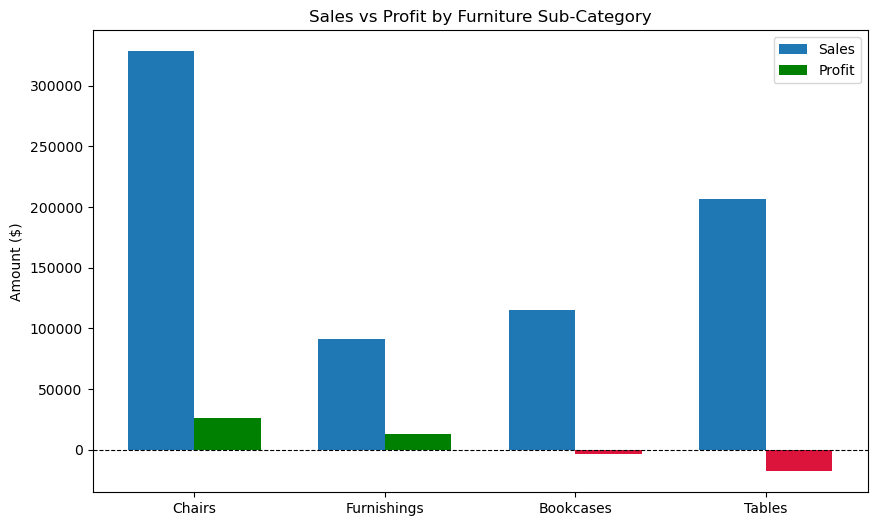

In [19]:
fig, ax= plt.subplots(figsize=(10, 6))
x = range(len(sub_profit.index))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], sub_profit['Sales'],width, label='Sales')
bars2 = ax.bar([i + width/2 for i in x], sub_profit['Profit'],width, label='Profit',color=['crimson' if v < 0 else 'green' for v in sub_profit['Profit']])
ax.set_xticks(x)
ax.set_xticklabels(sub_profit.index)
ax.set_title('Sales vs Profit by Furniture Sub-Category')
ax.set_ylabel('Amount ($)')
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.legend()
plt.show()

**Result**
Furniture's profit problem is concentrated in exactly 2 sub-categories:
* **Tables** :- highest discount (26.1%) → loss of 17,725 USD
* **Bookcases** :- second highest discount (21.1%) → loss of 3,472 USD

Both profitable sub-categories stay below the 20% discount threshold:
* **Chairs** (17%) :- profit of 26,590 USD
* **Furnishings** (13.8%) :- profit of 13,059 USD

### Key Insights
* Technology is the most profitable category (145K USD) despite 
  not having the highest sales.
* Furniture has high sales but extremely low profit — 
  deep dive in Section 3.1 reveals Tables (-17K USD) and 
  Bookcases (-3.4K USD) are the culprits due to excessive discounting.
* Office Supplies maintains healthy profit with moderate sales.
* Discount strategy on Furniture sub-categories needs immediate review.

## Section 4: Monthly Sales Trend (2014-2017)
Analyzing how sales have trended over time to identify growth patterns and seasonal peaks.

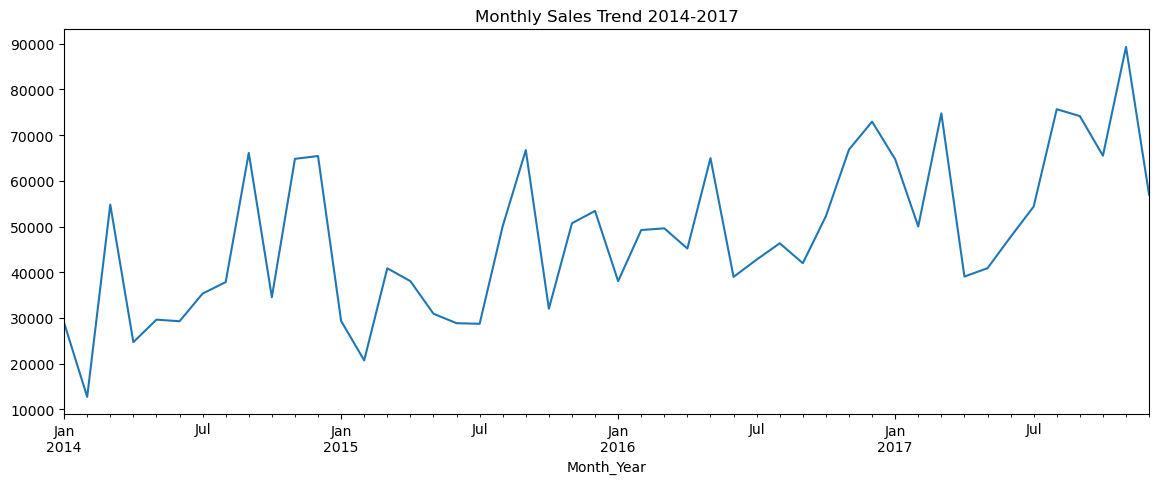

In [20]:
df['Month_Year']=df['Order Date'].dt.to_period('M')
monthly= df.groupby('Month_Year')['Sales'].sum()
monthly.plot(figsize=(14,5))
plt.title('Monthly Sales Trend 2014-2017')
plt.show()

### Key Insights
* Clear upward sales trend from 2014 to 2017 business is on great path
* Sales consistenrly peak in November and December every year , suggesting strong seasonal demand during the holidays period.

## Section 5: Customer Segment Analysis
Understanding which customer segment contributes the most to total revenue.

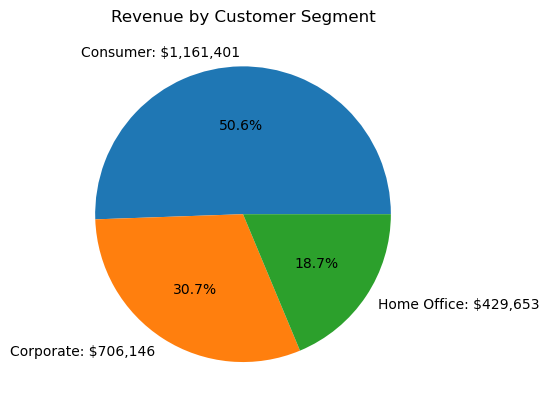

In [21]:
segment=df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
labels = [f'{name}: ${val:,.0f}' for name, val in segment.items()]
plt.pie(segment.values,labels=labels,autopct='%1.1f%%')
plt.title('Revenue by Customer Segment')
plt.show()

### Key Insights
**Consumer** segment dominates with **50.6%**, **Corporate** with **30.7%** and **Home Office** has **18.7%** of total revenue.  
* Marketing should be priortized on Consumer while finding ways to grow the Corporate and Home Office has smaller market segment compared to the other two segments.

## Section 6: Impact of Discount on Profit
Analyzing whether offering discounts is helping or hurting the business.  
This is a critical business question for pricing strategy.

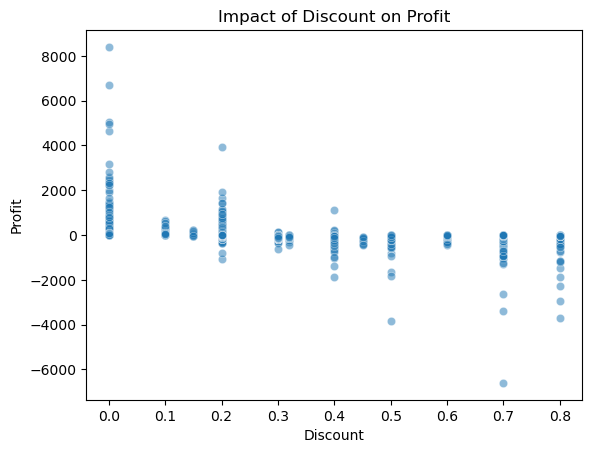

In [22]:
sns.scatterplot(x='Discount',y='Profit',data=df,alpha=0.5)
plt.title('Impact of Discount on Profit')
plt.show()

### Key Insights
* There is inverse realtion between discount and profit.
* Orders with discounts above 20% frequently result in losses.
* The business should reconsider its discount strategy.

## Section 7: Pareto Analysis
Analyzing whether revenue is spread evenly across customers or concentrated in a few.  
This helps decide where retention effort should be focused.

In [23]:
customers_data= df.groupby('Customer ID').agg(Total_sales=('Sales', 'sum'),Total_profit=('Profit', 'sum')).sort_values(by='Total_sales', ascending=False).reset_index()
cutoff = int(len(customers_data) * 0.10)
top_10_sales= customers_data['Total_sales'].iloc[:cutoff].sum()
Total_sales=df['Sales'].sum()
top10= (top_10_sales / Total_sales) * 100
print(f"The top 10% of our customers generate {top10:.2f}% of total revenue.")

The top 10% of our customers generate 30.62% of total revenue.


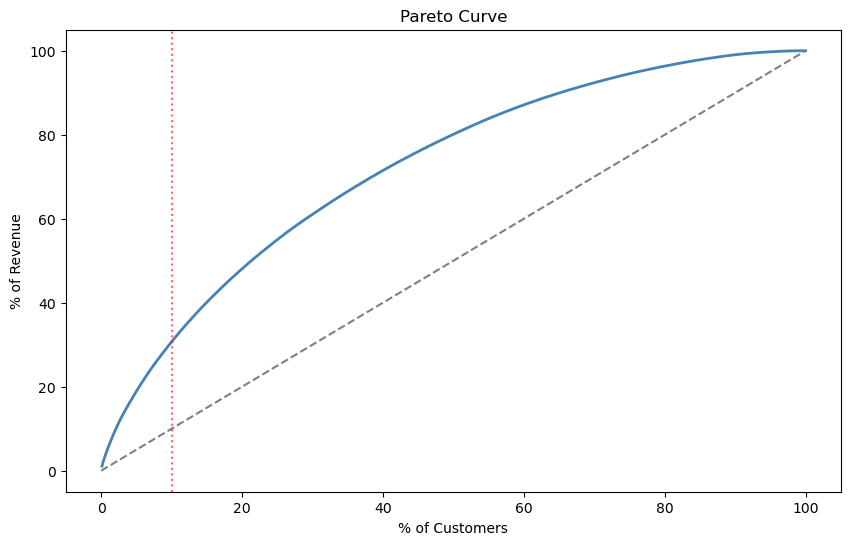

In [24]:
customers_data['sales'] = customers_data['Total_sales'].cumsum() / Total_sales * 100
customers_data['customers'] = (customers_data.index + 1) / len(customers_data) * 100
plt.figure(figsize=(10,6))
plt.plot(customers_data['customers'], customers_data['sales'], color='steelblue', linewidth=2)
plt.plot([0,100],[0,100], linestyle='--', color='gray')
plt.axvline(10, color='red', linestyle=':', alpha=0.6)
plt.xlabel('% of Customers')
plt.ylabel('% of Revenue')
plt.title('Pareto Curve')
plt.show()

### Key Insights

* Top **10%** of customers generate **30%** of total revenue — a small group carries a disproportionate share of the business.
* The Pareto curve sits well above the equal-distribution line, confirming revenue is concentrated, not evenly spread.
* Losing even a handful of these top customers would hit revenue harder than losing an equivalent number from the bottom **50%**.
* Retention and account management effort should be weighted toward this top decile rather than spread evenly across the customer base.

## Section 8: RFM Customer Segmentation

RFM analysis scores every customer on 3 dimensions:  

 **Recency (R):** How recently did they purchase?  
 **Frequency (F):** How often do they purchase?  
 **Monetary (M):** How much have they spent in total?

Each customer scores 1-4 on each dimension and is grouped into segments helping the business decide who to retain, who to re-engage and who deprioritize.

In [25]:
reference_date = df['Order Date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg(Recency   = ('Order Date', lambda x: (reference_date - x.max()).days), 
                                    Frequency = ('Order ID', 'nunique'), Monetary  = ('Sales', 'sum')).round(2)
rfm.head(10)

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,185,5,5563.56
AA-10375,49,9,1056.39
AA-10480,260,4,1790.51
AA-10645,234,6,5086.94
AB-10015,446,3,886.15
AB-10060,106,8,7755.63
AB-10105,42,10,14473.57
AB-10150,42,5,966.71
AB-10165,107,8,1113.85


In [26]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1]).astype(int)

# Higher frequency = better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)

# Higher monetary = better
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4]).astype(int)

# RFM Score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
AA-10315,185,5,5563.56,2,1,4,214
AA-10375,49,9,1056.39,3,4,1,341
AA-10480,260,4,1790.51,1,1,2,112
AA-10645,234,6,5086.94,1,2,4,124
AB-10015,446,3,886.15,1,1,1,111
AB-10060,106,8,7755.63,2,3,4,234
AB-10105,42,10,14473.57,3,4,4,344
AB-10150,42,5,966.71,3,1,1,311
AB-10165,107,8,1113.85,2,3,1,231


In [27]:
def segment_customer(row):
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champion'
    elif r >= 3 and f >= 2:
        return 'Loyal Customer'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalist'
    elif r == 2 and f >= 2:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Big Spender at Risk'
    else:
        return 'Lost'
rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm['Segment'].value_counts()

Segment
Lost                   179
Champion               175
At Risk                166
Loyal Customer         152
Potential Loyalist      72
Big Spender at Risk     49
Name: count, dtype: int64

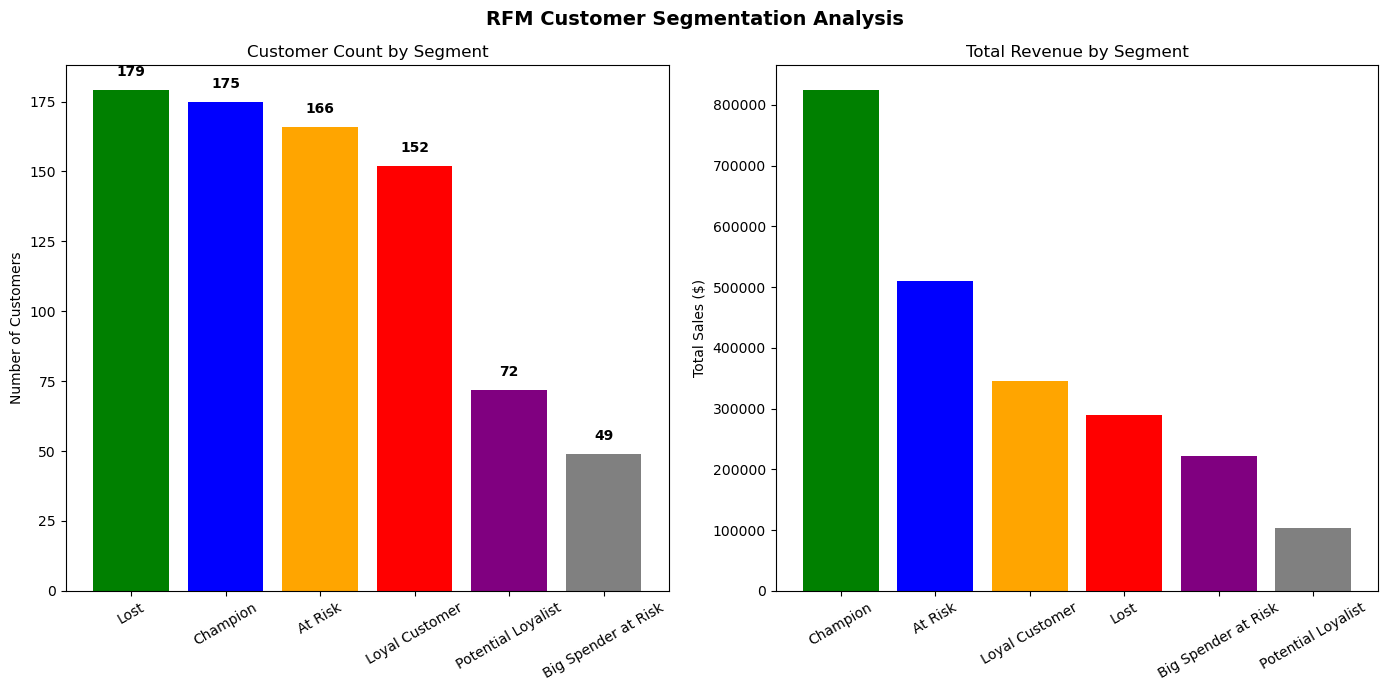

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Customer count per segment
segment_counts = rfm['Segment'].value_counts()
colors = ['Green','Blue','Orange','Red','Purple','Gray']
axes[0].bar(segment_counts.index, segment_counts.values, color=colors)
axes[0].set_title('Customer Count by Segment')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=30)
for i, val in enumerate(segment_counts.values):
    axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold')

# Revenue per segment
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
axes[1].bar(segment_revenue.index, segment_revenue.values, color=colors)
axes[1].set_title('Total Revenue by Segment')
axes[1].set_ylabel('Total Sales ($)')
axes[1].tick_params(axis='x', rotation=30)
plt.suptitle('RFM Customer Segmentation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

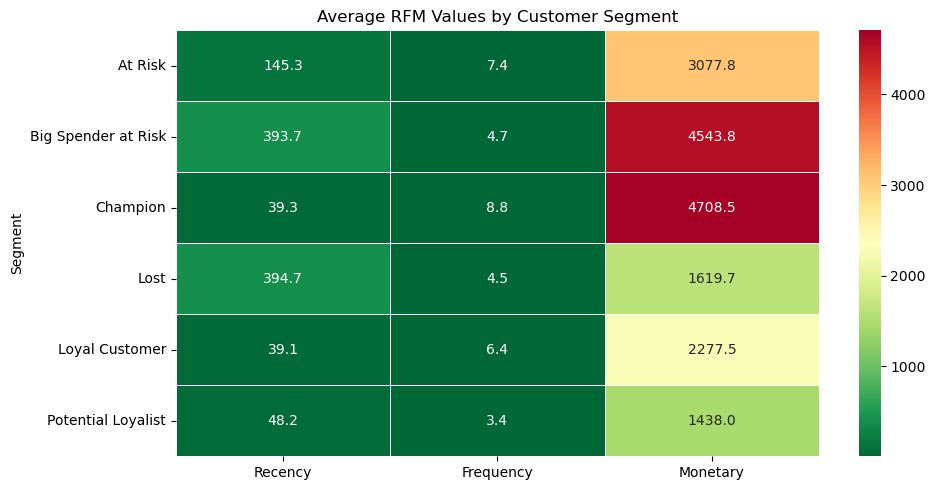

,Recency,Frequency,Monetary
Segment,,,
At Risk,145.3,7.4,3077.8
Big Spender at Risk,393.7,4.7,4543.8
Champion,39.3,8.8,4708.5
Lost,394.7,4.5,1619.7
Loyal Customer,39.1,6.4,2277.5
Potential Loyalist,48.2,3.4,1438.0


In [29]:
segment_summary = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1)
plt.figure(figsize=(10, 5))
sns.heatmap(segment_summary, annot=True, fmt='.1f', cmap='RdYlGn_r' if 'Recency' else 'RdYlGn',linewidths=0.5)
plt.title('Average RFM Values by Customer Segment')
plt.tight_layout()
plt.show()
segment_summary

### Key Insights

* Business has 793 unique customers split across 6 segments
* **Champions (175)** — most valuable segment, buying every 
  39 days, 8.8x frequency, 4,708 USD avg spend. Retain at all costs.

* **Lost (179)** — largest segment, gone for 394 days avg. 
  Recovery cost too high — deprioritize.

* **At Risk (166)** — URGENT. Were behaving like Champions 
  but stopped buying 145 days ago. Prime win-back target.

* **Big Spender at Risk (49)** — smallest but most dangerous. 
  4,543 USD avg spend but inactive for 393 days. 
  Losing these 49 customers = ~222K USD potential revenue loss.

* At Risk + Big Spender at Risk combined (215 customers) 
  represent the highest ROI win-back opportunity in the business.

## Conclusion & Business Recommendations

Based on this analysis, here are the key recommendations:

1. **Focus on West and East regions** :- highest revenue generators.
   South needs targeted customer acquisition and retention campaigns,not pricing changes.

2. **Invest more in Technology** :- highest profit margins (145K USD).
   Scale what's already working.

3. **Cap discounts on Tables and Bookcases at 15%** :- both are operating at a loss purely due to excessive discounting (26% and 21%).
   Chairs and Furnishings require no intervention.

4. **Capitalize on Q4 seasonality** :- sales peak every November and December.
   Plan inventory and marketing campaigns around this.

5. **Re-evaluate discount policy globally** :- orders with discounts above 20% consistently result in losses across all categories.

6. **Immediate win back campaign for At Risk segment** :- 166 customers who previously behaved like Champions have stopped buying.
   Combined with Big Spender at Risk (49 customers), this represents 500K USD in recoverable revenue.

7. **Protect Champions (175 customers)** :- generating 4,708 USD avg spend with 8.8x purchase frequency.
   Losing even 10% of this segment would significantly impact total revenue.

8. **Grow Corporate segment** :- currently at 30.7% vs Consumer's 50.6%.
   Untapped potential given Corporate customers tend to have higher order values.

This analysis was performed using Python on the Sample Superstore 
dataset to demonstrate data analysis and business insight generation skills.